# Online Shoppers Purchasing Intention Dataset
Data loading, cleaning, exploratory analysis, and modeling guidance.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = Path("online_shoppers_intention.csv")
OUTPUT_DIR = Path("online_shoppers_outputs")
FIGURE_DIR = OUTPUT_DIR / "figures"
OUTPUT_DIR.mkdir(exist_ok=True)
FIGURE_DIR.mkdir(exist_ok=True)

## 1. Load and inspect the dataset

In [2]:
raw = pd.read_csv(DATA_PATH)
print("Shape:", raw.shape)
display(raw.head())
raw.info()

Shape: (12330, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [3]:
display(raw.isna().sum().to_frame("Missing Values"))
print("Exact duplicate rows:", raw.duplicated().sum())
display(raw.describe(include="all").transpose())

,Missing Values
Administrative,0
Administrative_Duration,0
Informational,0
Informational_Duration,0
ProductRelated,0
ProductRelated_Duration,0
BounceRates,0
ExitRates,0
PageValues,0
SpecialDay,0


Exact duplicate rows: 125


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Administrative,12330.0,NaN,NaN,NaN,2.315166,3.321784,0.0,0.0,1.0,4.0,27.0
Administrative_Duration,12330.0,NaN,NaN,NaN,80.818611,176.779107,0.0,0.0,7.5,93.25625,3398.75
Informational,12330.0,NaN,NaN,NaN,0.503569,1.270156,0.0,0.0,0.0,0.0,24.0
Informational_Duration,12330.0,NaN,NaN,NaN,34.472398,140.749294,0.0,0.0,0.0,0.0,2549.375
ProductRelated,12330.0,NaN,NaN,NaN,31.731468,44.475503,0.0,7.0,18.0,38.0,705.0
ProductRelated_Duration,12330.0,NaN,NaN,NaN,1194.74622,1913.669288,0.0,184.1375,598.936905,1464.157214,63973.52223
BounceRates,12330.0,NaN,NaN,NaN,0.022191,0.048488,0.0,0.0,0.003112,0.016813,0.2
ExitRates,12330.0,NaN,NaN,NaN,0.043073,0.048597,0.0,0.014286,0.025156,0.05,0.2
PageValues,12330.0,NaN,NaN,NaN,5.889258,18.568437,0.0,0.0,0.0,0.0,361.763742
SpecialDay,12330.0,NaN,NaN,NaN,0.061427,0.198917,0.0,0.0,0.0,0.0,1.0


## 2. Clean the data

In [4]:
clean = raw.copy()
for column in ["Month", "VisitorType"]:
    clean[column] = clean[column].astype(str).str.strip()
clean["Month"] = clean["Month"].str[:3].str.title()

nonnegative_columns = [
    "Administrative", "Administrative_Duration", "Informational",
    "Informational_Duration", "ProductRelated", "ProductRelated_Duration",
    "BounceRates", "ExitRates", "PageValues", "SpecialDay"
]
for column in nonnegative_columns:
    clean[column] = clean[column].clip(lower=0)
for column in ["BounceRates", "ExitRates", "SpecialDay"]:
    clean[column] = clean[column].clip(0, 1)

clean = clean.drop_duplicates().reset_index(drop=True)
print("Cleaned shape:", clean.shape)
print("Rows removed:", len(raw) - len(clean))
print("Remaining missing values:", clean.isna().sum().sum())

Cleaned shape: (12205, 18)
Rows removed: 125
Remaining missing values: 0


## 3. Detect outliers and reduce skew without deleting valid sessions

In [5]:
outlier_features = [
    "Administrative", "Administrative_Duration", "Informational",
    "Informational_Duration", "ProductRelated", "ProductRelated_Duration",
    "BounceRates", "ExitRates", "PageValues", "SpecialDay"
]
rows = []
for column in outlier_features:
    q1, q3 = clean[column].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    count = ((clean[column] < lower) | (clean[column] > upper)).sum()
    rows.append([column, count, lower, upper, clean[column].quantile(.99), clean[column].max()])
outliers = pd.DataFrame(rows, columns=["Feature", "IQR Outliers", "Lower", "Upper", "99th Percentile", "Maximum"])
display(outliers.sort_values("IQR Outliers", ascending=False))

model_ready = clean.copy()
skewed_features = [
    "Administrative_Duration", "Informational_Duration", "ProductRelated",
    "ProductRelated_Duration", "BounceRates", "ExitRates", "PageValues"
]
for column in skewed_features:
    model_ready[f"log1p_{column}"] = np.log1p(model_ready[column])

,Feature,IQR Outliers,Lower,Upper,99th Percentile,Maximum
8,PageValues,2730,0.000000,0.000000,86.108689,361.763742
2,Informational,2631,0.000000,0.000000,6.000000,24.000000
3,Informational_Duration,2405,0.000000,0.000000,722.379200,2549.375000
6,BounceRates,1428,-0.025000,0.041667,0.200000,0.200000
7,ExitRates,1325,-0.037217,0.099977,0.200000,0.200000
9,SpecialDay,1249,0.000000,0.000000,1.000000,1.000000
1,Administrative_Duration,1149,-142.050000,236.750000,838.704889,3398.750000
4,ProductRelated,1007,-37.000000,83.000000,221.000000,705.000000
5,ProductRelated_Duration,951,-1733.232143,3403.386905,8704.271573,63973.522230
0,Administrative,404,-6.000000,10.000000,14.000000,27.000000


## 4. Exploratory visualizations

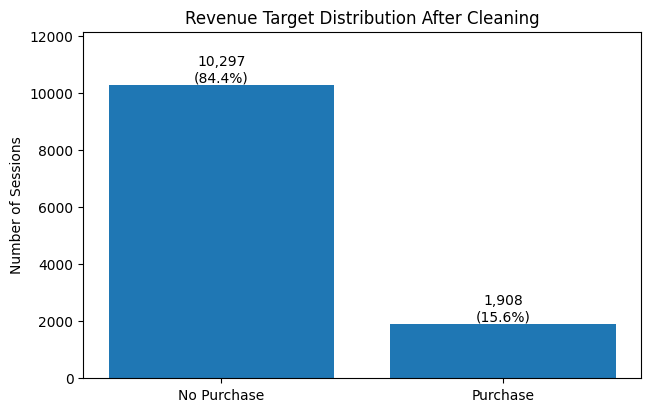

In [6]:
counts = clean["Revenue"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(7.2, 4.5))
labels = ["No Purchase", "Purchase"]
values = [int(counts.get(False, 0)), int(counts.get(True, 0))]
bars = ax.bar(labels, values)
ax.set_title("Revenue Target Distribution After Cleaning")
ax.set_ylabel("Number of Sessions")
for bar, value in zip(bars, values):
    ax.text(bar.get_x()+bar.get_width()/2, value, f"{value:,}\n({value/sum(values):.1%})", ha="center", va="bottom")
ax.set_ylim(0, max(values) * 1.18)
plt.show()

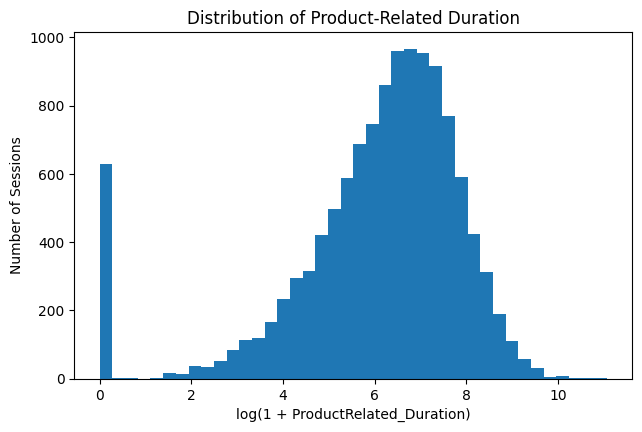

In [7]:
fig, ax = plt.subplots(figsize=(7.2, 4.5))
ax.hist(np.log1p(clean["ProductRelated_Duration"]), bins=40)
ax.set_title("Distribution of Product-Related Duration")
ax.set_xlabel("log(1 + ProductRelated_Duration)")
ax.set_ylabel("Number of Sessions")
plt.show()

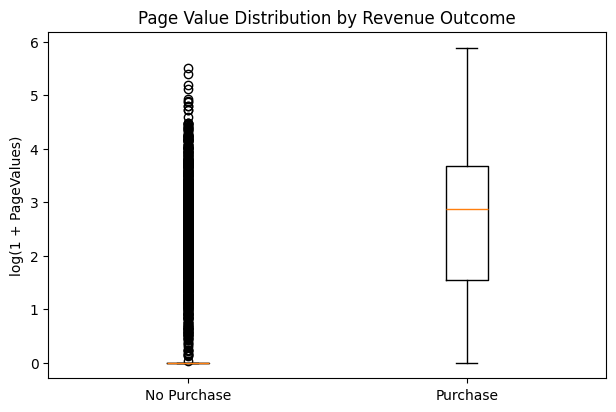

In [8]:
fig, ax = plt.subplots(figsize=(7.2, 4.5))
no_purchase = np.log1p(clean.loc[~clean["Revenue"], "PageValues"])
purchase = np.log1p(clean.loc[clean["Revenue"], "PageValues"])
ax.boxplot([no_purchase, purchase], tick_labels=["No Purchase", "Purchase"], showfliers=True)
ax.set_title("Page Value Distribution by Revenue Outcome")
ax.set_ylabel("log(1 + PageValues)")
plt.show()

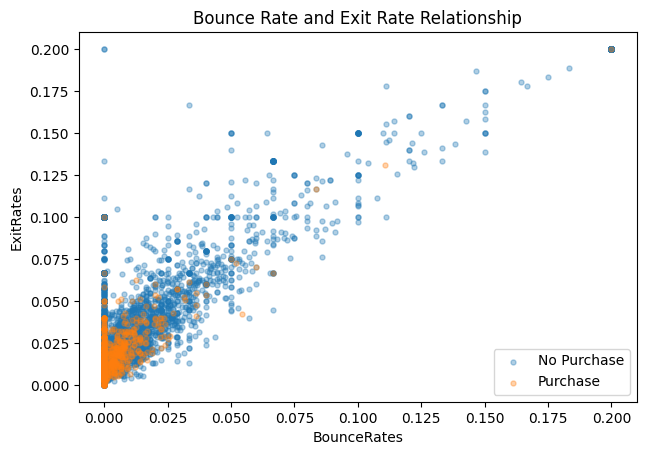

In [9]:
fig, ax = plt.subplots(figsize=(7.2, 4.8))
plot_data = clean.sample(n=min(4500, len(clean)), random_state=42)
for outcome, label in [(False, "No Purchase"), (True, "Purchase")]:
    group = plot_data[plot_data["Revenue"] == outcome]
    ax.scatter(group["BounceRates"], group["ExitRates"], alpha=.35, s=13, label=label)
ax.set_title("Bounce Rate and Exit Rate Relationship")
ax.set_xlabel("BounceRates")
ax.set_ylabel("ExitRates")
ax.legend()
plt.show()

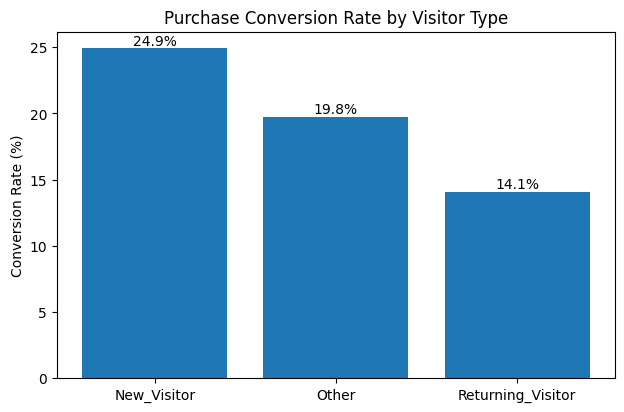

In [10]:
visitor_conversion = clean.groupby("VisitorType")["Revenue"].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7.2, 4.5))
bars = ax.bar(visitor_conversion.index, visitor_conversion.values*100)
ax.set_title("Purchase Conversion Rate by Visitor Type")
ax.set_ylabel("Conversion Rate (%)")
for bar, value in zip(bars, visitor_conversion.values*100):
    ax.text(bar.get_x()+bar.get_width()/2, value, f"{value:.1f}%", ha="center", va="bottom")
plt.show()

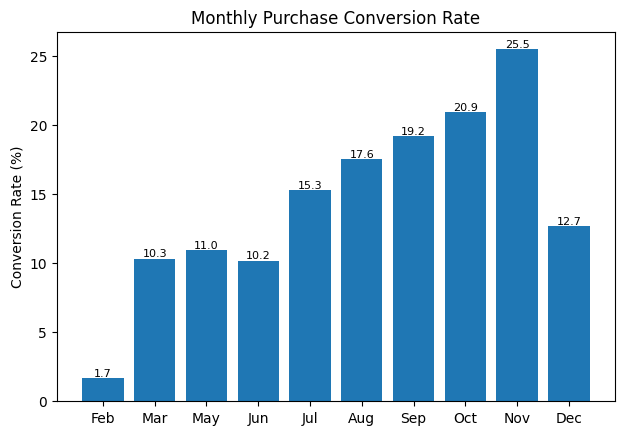

In [11]:
month_order = ["Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec", "Jan"]
available = [m for m in month_order if m in set(clean["Month"])]
month_conversion = clean.groupby("Month")["Revenue"].mean().reindex(available)
fig, ax = plt.subplots(figsize=(7.2, 4.8))
bars = ax.bar(month_conversion.index, month_conversion.values*100)
ax.set_title("Monthly Purchase Conversion Rate")
ax.set_ylabel("Conversion Rate (%)")
for bar, value in zip(bars, month_conversion.values*100):
    ax.text(bar.get_x()+bar.get_width()/2, value, f"{value:.1f}", ha="center", va="bottom", fontsize=8)
plt.show()

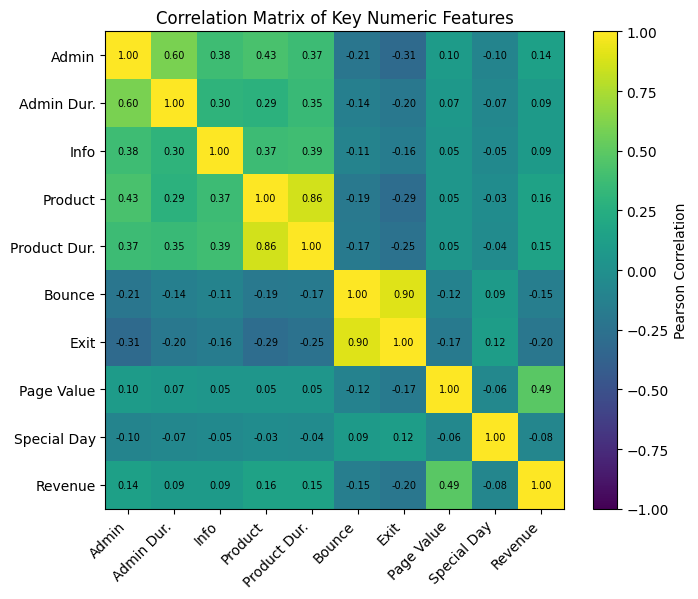

In [12]:
numeric = clean.select_dtypes(include=np.number).copy()
numeric["Revenue"] = clean["Revenue"].astype(int)
features = ["Administrative", "Administrative_Duration", "Informational", "ProductRelated",
            "ProductRelated_Duration", "BounceRates", "ExitRates", "PageValues", "SpecialDay", "Revenue"]
corr = numeric[features].corr()
fig, ax = plt.subplots(figsize=(7.4, 6.2))
image = ax.imshow(corr.values, aspect="auto", vmin=-1, vmax=1)
labels = ["Admin", "Admin Dur.", "Info", "Product", "Product Dur.", "Bounce", "Exit", "Page Value", "Special Day", "Revenue"]
ax.set_xticks(range(len(labels))); ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha="right"); ax.set_yticklabels(labels)
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center", fontsize=7)
fig.colorbar(image, ax=ax, label="Pearson Correlation")
ax.set_title("Correlation Matrix of Key Numeric Features")
plt.show()

## 5. Numerical insights

In [13]:
display(clean.groupby("Revenue")[["ProductRelated", "ProductRelated_Duration", "BounceRates", "ExitRates", "PageValues"]].agg(["mean", "median"]))
display(clean.groupby("VisitorType")["Revenue"].agg(["count", "sum", "mean"]).sort_values("mean", ascending=False))
display(clean.groupby("Month")["Revenue"].agg(["count", "sum", "mean"]).reindex(available))
display(numeric.corr()["Revenue"].sort_values(ascending=False).to_frame("Correlation with Revenue"))

ProductRelated         ... PageValues           
                  mean median  ...       mean     median
Revenue                        ...                      
False        29.050403   16.0  ...   1.999985   0.000000
True         48.210168   29.0  ...  27.264518  16.758134

[2 rows x 10 columns]

,count,sum,mean
VisitorType,,,
New_Visitor,1693,422,0.249262
Other,81,16,0.197531
Returning_Visitor,10431,1470,0.140926


,count,sum,mean
Month,,,
Feb,181,3,0.016575
Mar,1860,192,0.103226
May,3329,365,0.109643
Jun,285,29,0.101754
Jul,432,66,0.152778
Aug,433,76,0.175520
Sep,448,86,0.191964
Oct,549,115,0.209472
Nov,2982,760,0.254863


,Correlation with Revenue
Revenue,1.000000
PageValues,0.491894
ProductRelated,0.156042
ProductRelated_Duration,0.150077
Administrative,0.136330
Informational,0.093626
Administrative_Duration,0.091768
Informational_Duration,0.069358
Browser,0.024052
TrafficType,-0.005618


## 6. Save cleaned datasets

In [14]:
clean.to_csv(OUTPUT_DIR / "online_shoppers_cleaned.csv", index=False)
model_ready.to_csv(OUTPUT_DIR / "online_shoppers_model_ready.csv", index=False)
print("Files saved to", OUTPUT_DIR.resolve())

Files saved to /mnt/data/online_shoppers_project/online_shoppers_outputs
